In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
import ray

import poppy
from poppy.poppy_core import PlaneType

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import stppsf
import stppsf.utils as utils
from stppsf.math_module import xp, _scipy, ensure_np_array
from stppsf.imshows import imshow1, imshow2, imshow3
import stppsf.esc_fresnel as esc
import stppsf.esc_optics as esc_optics

import psd_utils

import pathlib


In [2]:
opd_rms_vals = {
    'm1': 20*u.nm, 
    'm2': 16*u.nm, 
    'm3': 10*u.nm, 
    'm4': 10*u.nm, 
    'oap1': 6*u.nm,
    'fm1': 6*u.nm, 
    'oap2': 6*u.nm, 
    'oap3': 6*u.nm, 
    'fsm': 6*u.nm, 
    'fm2': 6*u.nm, 
    'oap4': 6*u.nm, 
    'oap5': 6*u.nm, 
    'input_lp': 6*u.nm, 
    'input_qwp': 6*u.nm, 
    'oap6': 6*u.nm, 
    'oap7': 6*u.nm, 
    # 'oap8_locam': 6*u.nm, 
    'oap9': 6*u.nm, 
    'collimator': 6*u.nm, 
    'filter': 6*u.nm, 
    'output_qwp': 6*u.nm,
    'output_lp': 6*u.nm, 
    'oap10': 6*u.nm, 
}

Propagating wavelength 650.000 nm.
PSF calculated in 0.369s


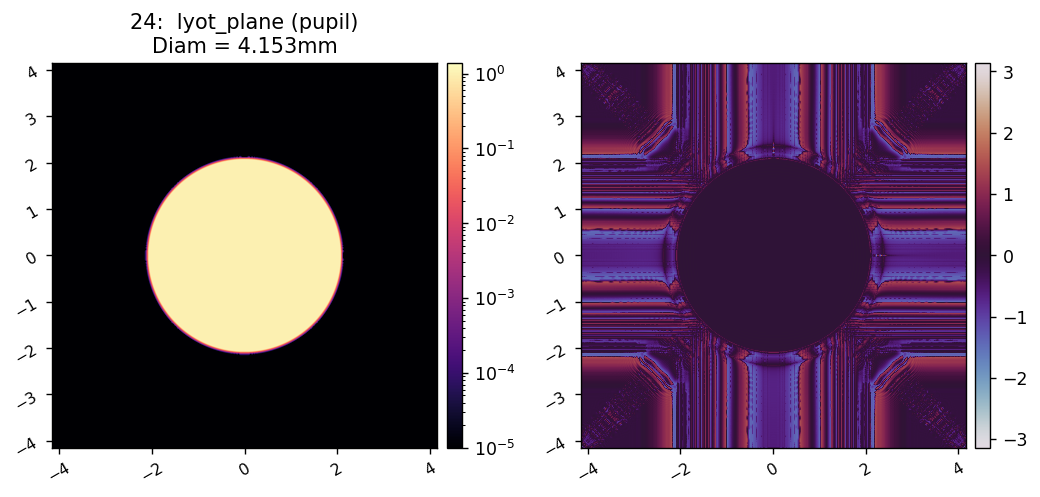

In [3]:
reload(esc)
# reload(optics)

M = esc.single(npix=1000, oversample=2.048)
# M.use_vortex = True

# M.lyot_corr = -0.45*u.mm

wfs = M.calc_wfs()

i = 24 # Lyot
wf = wfs[i]
imshow2(wf.intensity, wf.phase, f'{i:d}: '+wf.location[5:] + f'\nDiam = {2*wf.spot_radius().to_value(u.mm):.3f}mm', 
        pxscl=wf.pixelscale.to(u.mm/u.pix), npix=2*M.npix, cmap2='twilight',
        lognorm1=True, vmin1=1e-5,
        # vmin2=-0.01, vmax2=0.01,
        )

In [4]:
def get_wf_index(optic_name):
    found = False
    for i in range(len(wfs)):
        if optic_name in wfs[i].location.lower():
            ind = i
            found = True
            break
    if found:
        return i
    else:
        raise ValueError(f'Optic {optic_name} not found')
    
print(get_wf_index('oap1'), get_wf_index('output_lp'), get_wf_index('fsm'))

6 31 12


2 m2  m2
	 Diam = 0.71473, Pixelscale = 2.18e-04, Dimensions = 3286



09/11/2024 03:50:53PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:50:53PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.2722445290692631
PSD now scaled to RMS.


09/11/2024 03:51:10PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 1.369


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 1.369


09/11/2024 03:51:13PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 1.6000e+01


DEBUG:__psd_utils__:RMS of map at end of create_map is: 1.6000e+01


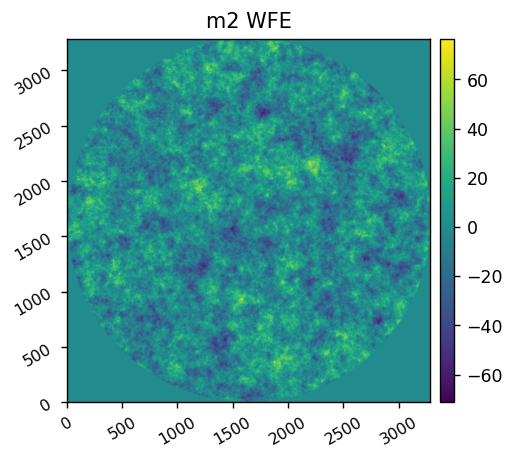

Saved data to:  ../stppsf/wfe-maps/m2_full.fits
4 m4  m4 (pupil)
	 Diam = 0.09634, Pixelscale = 3.17e-05, Dimensions = 3036



09/11/2024 03:51:27PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:51:27PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.10474255361088625
PSD now scaled to RMS.


09/11/2024 03:51:39PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 10.685


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 10.685


09/11/2024 03:51:40PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 1.0000e+01


DEBUG:__psd_utils__:RMS of map at end of create_map is: 1.0000e+01


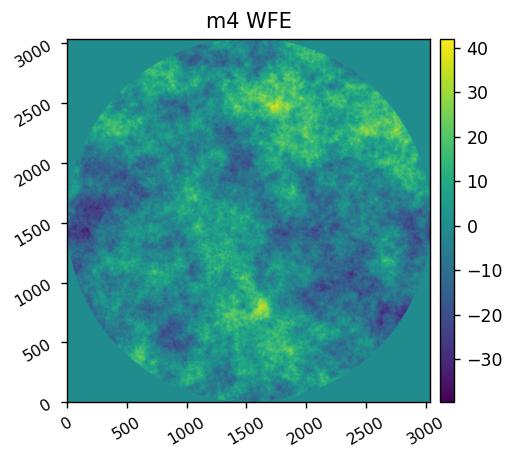

Saved data to:  ../stppsf/wfe-maps/m4_full.fits
6 oap1  oap1
	 Diam = 0.05080, Pixelscale = 1.27e-05, Dimensions = 3992



09/11/2024 03:51:56PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:51:56PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.040277064489307186
PSD now scaled to RMS.


09/11/2024 03:52:17PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 19.878


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 19.878


09/11/2024 03:52:22PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


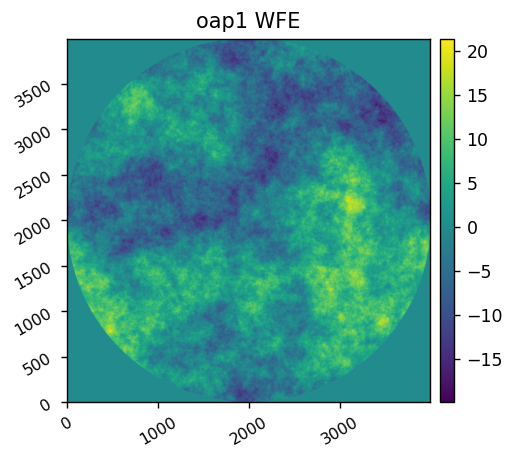

Saved data to:  ../stppsf/wfe-maps/oap1_full.fits
7 fm1  fm1
	 Diam = 0.05080, Pixelscale = 1.27e-05, Dimensions = 3992



09/11/2024 03:52:40PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:52:40PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.040277064489307186
PSD now scaled to RMS.


09/11/2024 03:53:04PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 20.184


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 20.184


09/11/2024 03:53:09PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


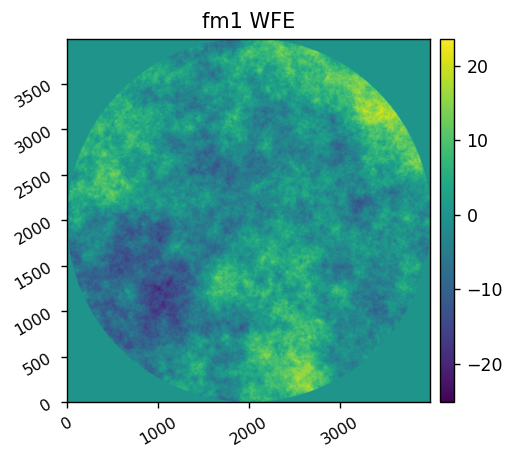

Saved data to:  ../stppsf/wfe-maps/fm1_full.fits
9 oap2  oap2
	 Diam = 0.02540, Pixelscale = 1.27e-05, Dimensions = 1996



09/11/2024 03:53:16PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:53:16PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.05188507730949212
PSD now scaled to RMS.


09/11/2024 03:53:19PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 42.130


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 42.130


09/11/2024 03:53:20PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


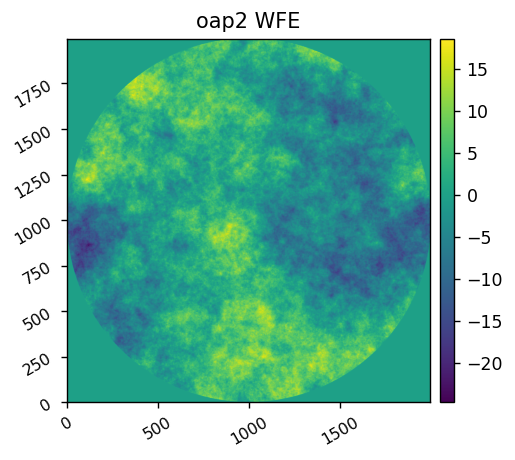

Saved data to:  ../stppsf/wfe-maps/oap2_full.fits
11 oap3  oap3
	 Diam = 0.02540, Pixelscale = 9.35e-06, Dimensions = 2717



09/11/2024 03:53:25PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:53:25PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.01768600652656466
PSD now scaled to RMS.


09/11/2024 03:53:31PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 82.577


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 82.577


09/11/2024 03:53:32PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


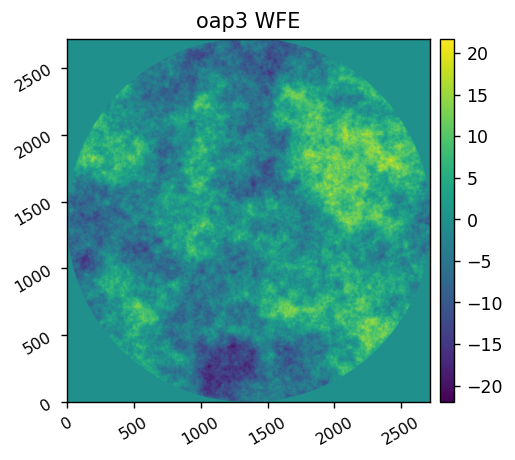

09/11/2024 03:53:33PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


Saved data to:  ../stppsf/wfe-maps/oap3_full.fits
12 fsm  FSM (pupilish)
	 Diam = 0.01000, Pixelscale = 9.35e-06, Dimensions = 1070

INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:53:33PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


09/11/2024 03:53:33PM - __psd_utils__ - DEBUG - freqs=array([7.06699103e+01, 1.58022723e+02, 2.12009731e+02, ...,
       7.54049268e+04, 7.54754973e+04, 7.55461342e+04])


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.08841593316340722
PSD now scaled to RMS.


09/11/2024 03:53:33PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 103.513


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 103.513


09/11/2024 03:53:33PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


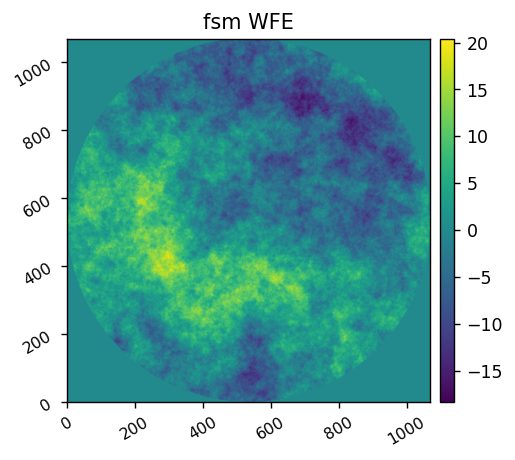

Saved data to:  ../stppsf/wfe-maps/fsm_full.fits
13 fm2  fm2
	 Diam = 0.02540, Pixelscale = 9.35e-06, Dimensions = 2717



09/11/2024 03:53:38PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:53:38PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.01768600652656466
PSD now scaled to RMS.


09/11/2024 03:53:47PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 81.471


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 81.471


09/11/2024 03:53:49PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


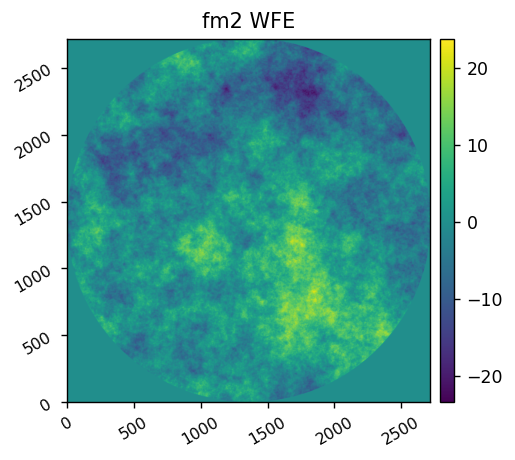

Saved data to:  ../stppsf/wfe-maps/fm2_full.fits
14 oap4  oap4
	 Diam = 0.02540, Pixelscale = 9.35e-06, Dimensions = 2717



09/11/2024 03:53:55PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:53:55PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.01768600652656466
PSD now scaled to RMS.


09/11/2024 03:54:00PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 74.983


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 74.983


09/11/2024 03:54:01PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


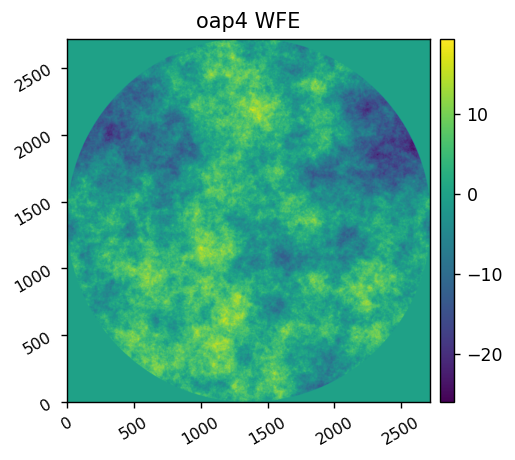

Saved data to:  ../stppsf/wfe-maps/oap4_full.fits
16 oap5  oap5
	 Diam = 0.02540, Pixelscale = 9.35e-06, Dimensions = 2717



09/11/2024 03:54:06PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:54:06PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.017686062571166176
PSD now scaled to RMS.


09/11/2024 03:54:15PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 71.479


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 71.479


09/11/2024 03:54:17PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


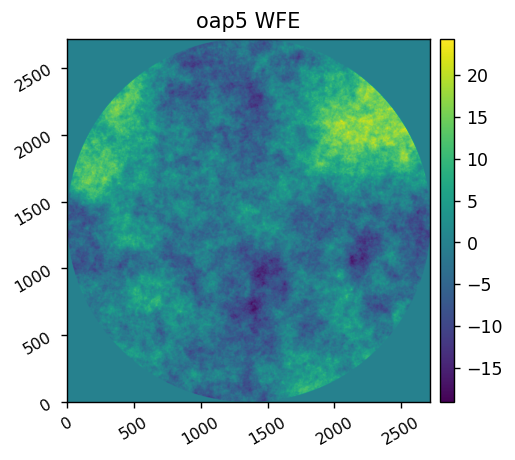

Saved data to:  ../stppsf/wfe-maps/oap5_full.fits
18 input_lp  input_lp
	 Diam = 0.02540, Pixelscale = 9.35e-06, Dimensions = 2717



09/11/2024 03:54:24PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:54:24PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.017686062571166176
PSD now scaled to RMS.


09/11/2024 03:54:29PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 91.668


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 91.668


09/11/2024 03:54:31PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


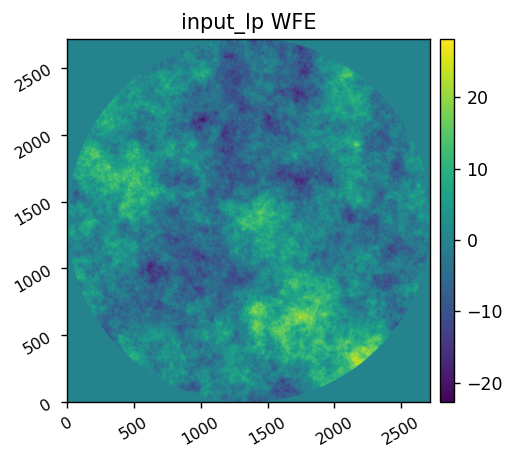

Saved data to:  ../stppsf/wfe-maps/input_lp_full.fits
19 input_qwp  input_qwp
	 Diam = 0.02540, Pixelscale = 9.35e-06, Dimensions = 2717



09/11/2024 03:54:36PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:54:36PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.017686062571166176
PSD now scaled to RMS.


09/11/2024 03:54:42PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 79.137


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 79.137


09/11/2024 03:54:44PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


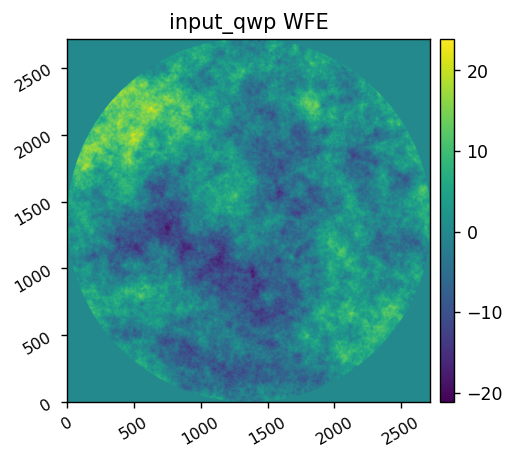

Saved data to:  ../stppsf/wfe-maps/input_qwp_full.fits
20 oap6  oap6
	 Diam = 0.02540, Pixelscale = 9.35e-06, Dimensions = 2717



09/11/2024 03:54:49PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:54:49PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.017686062571166176
PSD now scaled to RMS.


09/11/2024 03:54:56PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 83.265


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 83.265


09/11/2024 03:54:58PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


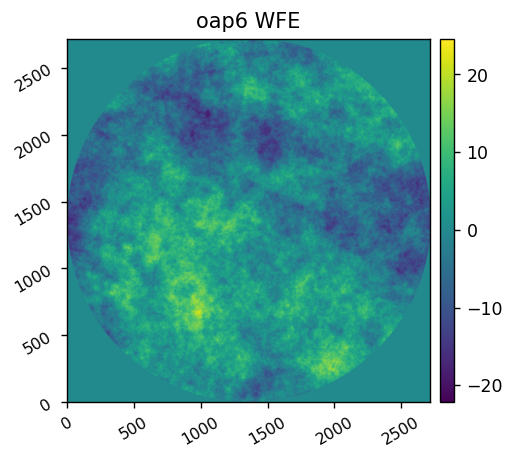

Saved data to:  ../stppsf/wfe-maps/oap6_full.fits
23 oap7  oap7
	 Diam = 0.02540, Pixelscale = 4.15e-06, Dimensions = 6116



09/11/2024 03:55:21PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:55:21PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.05172418549968879
PSD now scaled to RMS.


09/11/2024 03:56:00PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 48.533


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 48.533


09/11/2024 03:56:11PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


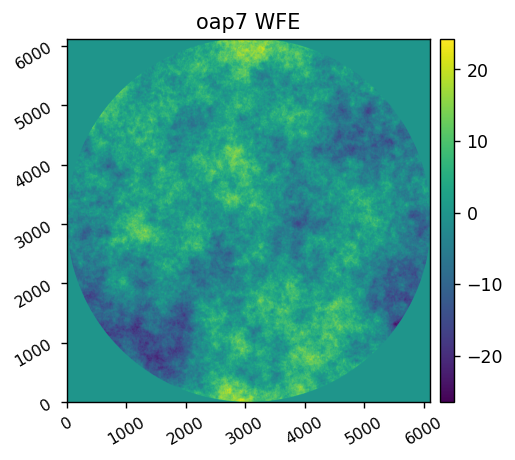

Saved data to:  ../stppsf/wfe-maps/oap7_full.fits
26 oap9  oap9
	 Diam = 0.02540, Pixelscale = 4.15e-06, Dimensions = 6116



09/11/2024 03:56:44PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:56:44PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.05172418549968879
PSD now scaled to RMS.


09/11/2024 03:57:23PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 40.627


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 40.627


09/11/2024 03:57:34PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


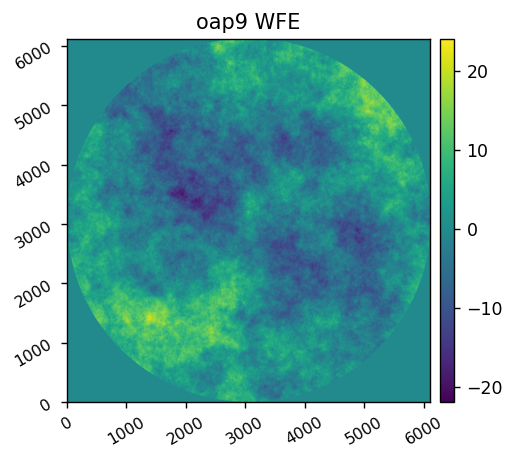

Saved data to:  ../stppsf/wfe-maps/oap9_full.fits
28 collimator  collimator
	 Diam = 0.02540, Pixelscale = 3.99e-06, Dimensions = 6361



09/11/2024 03:58:12PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:58:12PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.017670287652857393
PSD now scaled to RMS.


09/11/2024 03:58:57PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 81.993


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 81.993


09/11/2024 03:59:10PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


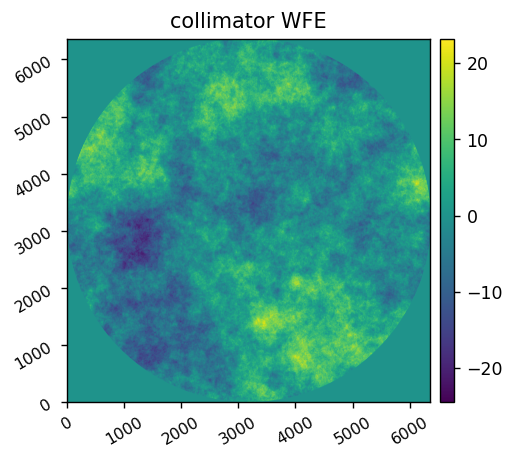

Saved data to:  ../stppsf/wfe-maps/collimator_full.fits
29 filter  filter
	 Diam = 0.02540, Pixelscale = 3.99e-06, Dimensions = 6361



09/11/2024 03:59:47PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 03:59:47PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.017670287652857393
PSD now scaled to RMS.


09/11/2024 04:00:32PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 77.355


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 77.355


09/11/2024 04:00:44PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


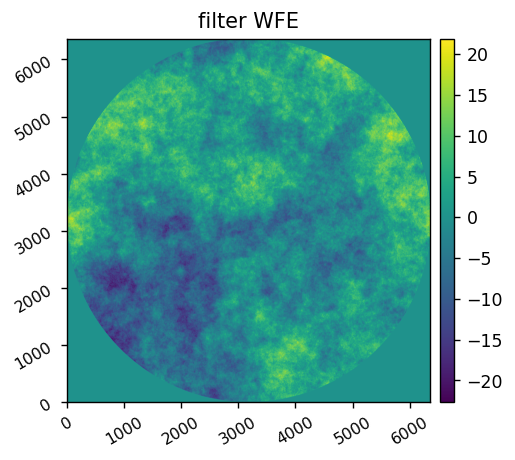

Saved data to:  ../stppsf/wfe-maps/filter_full.fits
30 output_qwp  Output_QWP
	 Diam = 0.02540, Pixelscale = 3.99e-06, Dimensions = 6361



09/11/2024 04:01:22PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 04:01:22PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.017670287652857393
PSD now scaled to RMS.


09/11/2024 04:02:05PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 88.106


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 88.106


09/11/2024 04:02:17PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


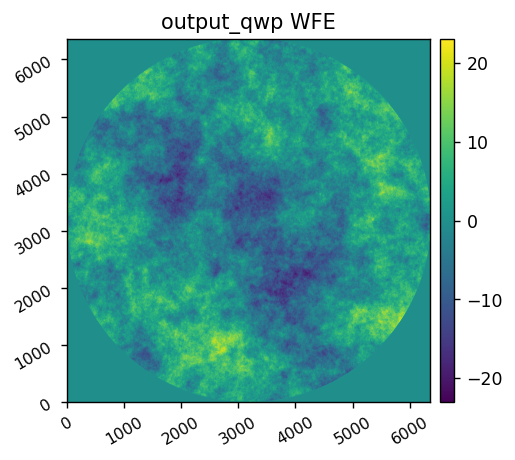

Saved data to:  ../stppsf/wfe-maps/output_qwp_full.fits
31 output_lp  Output_LP
	 Diam = 0.02540, Pixelscale = 3.99e-06, Dimensions = 6361



09/11/2024 04:02:55PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 04:02:55PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.017670287652857393
PSD now scaled to RMS.


09/11/2024 04:03:38PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 80.661


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 80.661


09/11/2024 04:03:51PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


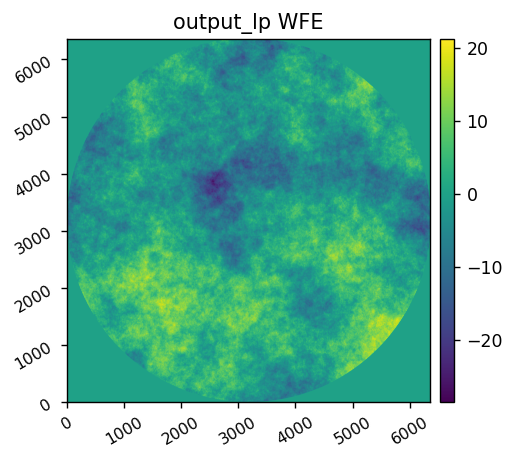

Saved data to:  ../stppsf/wfe-maps/output_lp_full.fits
32 oap10  oap10
	 Diam = 0.02540, Pixelscale = 3.99e-06, Dimensions = 6361



09/11/2024 04:04:27PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 04:04:27PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.017670287652857393
PSD now scaled to RMS.


09/11/2024 04:05:12PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 87.289


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 87.289


09/11/2024 04:05:25PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 6.0000e+00


DEBUG:__psd_utils__:RMS of map at end of create_map is: 6.0000e+00


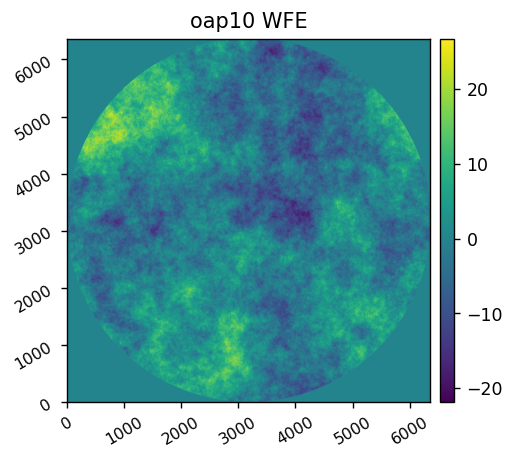

Saved data to:  ../stppsf/wfe-maps/oap10_full.fits


In [12]:
reload(esc_optics)

seed = 1234
opd_keys = list(opd_rms_vals.keys())
for i in range(len(opd_keys)):
    optic = opd_keys[i]
    if optic=='m1' or optic=='m3':
        continue # Skip M1 and M3 since these have unique geometries

    OD = esc_optics.diams[optic].to_value(u.m)
    ID = 0

    iwf = get_wf_index(optic)
    pwf = wfs[iwf]
    pxscl = pwf.pixelscale.to_value(u.m/u.pix)
    N = int(np.ceil(OD/pxscl))
    print(iwf, optic, wfs[iwf].location[5:])
    print(f'\t Diam = {OD:.5f}, Pixelscale = {pxscl:.2e}, Dimensions = {N :d}\n')

    pupil_max_width = OD
    a = 1  #   Will be determined from wfe_rms
    b = 10 # cycles/m
    c = 2.65
    wfe_rms = opd_rms_vals[optic].to_value(u.nm)

    psd_tools = psd_utils.PSDUtils()
    coords = psd_tools.coord_arrays((N,N), dx=pxscl)

    pupil_mask = np.zeros((N,N))
    pupil_mask[(np.abs(coords.r_grid) <= (OD / 2))] = 1
    pupil_mask[(np.abs(coords.r_grid) <= (ID / 2))] = 0

    psd = psd_tools.abc_psd(
        coords,
        a,
        b,
        c,
        rms=wfe_rms,
        k_min=None,
        k_max=None,
        rms_scaling=True,
        only_1d=False,
    )

    # create WFE map
    wfe = psd_tools.create_map(coords, psd, mask=pupil_mask, rms=wfe_rms, seed=seed)
    seed += 1

    imshow1(wfe.map, f'{optic} WFE', cmap='viridis')
    hdr = {
        'PIXELSCL':pxscl,
        'RMS':wfe_rms, 
        'A':a,
        'B':b,
        'C':c,
    }
    utils.save_fits(f'../stppsf/wfe-maps/{optic}_full.fits', wfe.map, header=hdr)

# Now make the map for M1

1 m1  m1
	 Diam = 6.50000, Pixelscale = 2.43e-03, Dimensions = 2675



09/11/2024 04:06:01PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 04:06:01PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.47595780070974686
PSD now scaled to RMS.


09/11/2024 04:06:07PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 0.154


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 0.154


09/11/2024 04:06:09PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 2.0000e+01


DEBUG:__psd_utils__:RMS of map at end of create_map is: 2.0000e+01


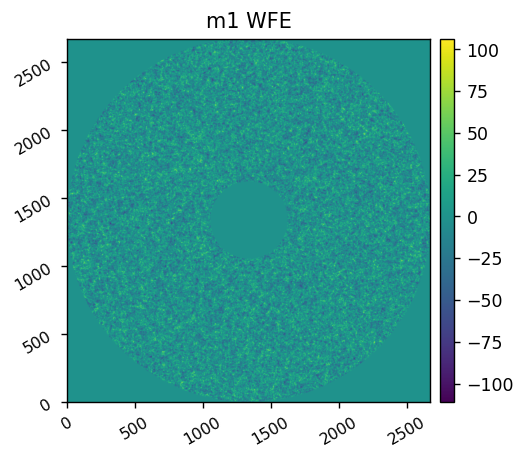

Saved data to:  ../stppsf/wfe-maps/m1_full.fits


In [13]:
reload(esc_optics)
optic = 'm1'
OD = esc_optics.diams[optic][0].to_value(u.m)
ID = esc_optics.diams[optic][1].to_value(u.m)

iwf = get_wf_index(optic)
pwf = wfs[iwf]
pxscl = pwf.pixelscale.to_value(u.m/u.pix)
N = int(np.ceil(OD/pxscl))
print(iwf, optic, wfs[iwf].location[5:])
print(f'\t Diam = {OD:.5f}, Pixelscale = {pxscl:.2e}, Dimensions = {N :d}\n')

pupil_max_width = OD
a = 1  # Will be determined from wfe_rms
b = 10 # cycles/m
c = 2.65
wfe_rms = opd_rms_vals[optic].to_value(u.nm)

psd_tools = psd_utils.PSDUtils()
coords = psd_tools.coord_arrays((N,N), dx=pxscl)

pupil_mask = np.zeros((N,N))
pupil_mask[(np.abs(coords.r_grid) <= (OD / 2))] = 1
pupil_mask[(np.abs(coords.r_grid) <= (ID / 2))] = 0

psd = psd_tools.abc_psd(
    coords,
    a,
    b,
    c,
    rms=wfe_rms,
    k_min=None,
    k_max=None,
    rms_scaling=True,
    only_1d=False,
)

# create WFE map
seed = 12345
wfe = psd_tools.create_map(coords, psd, mask=pupil_mask, rms=wfe_rms, seed=seed)
imshow1(wfe.map, f'{optic} WFE', cmap='viridis')

hdr = {
    'PIXELSCL':pxscl,
    'RMS':wfe_rms, 
    'A':a,
    'B':b,
    'C':c,
}
utils.save_fits(f'../stppsf/wfe-maps/{optic}_full.fits', wfe.map, header=hdr)

# Now make the map for M3

3 m3  m3
	 Diam = 0.70000, Pixelscale = 5.79e-05, Dimensions = 12088



09/11/2024 04:08:24PM - __psd_utils__ - INFO - No k_min set, using the minimum frequency.


INFO:__psd_utils__:No k_min set, using the minimum frequency.


09/11/2024 04:08:24PM - __psd_utils__ - INFO - No k_max set, using the maximum frequency.


INFO:__psd_utils__:No k_max set, using the maximum frequency.


...

DEBUG:__psd_utils__:2d normalization factor is abc.psd_2d_rms_scale=0.10465603974171545
PSD now scaled to RMS.


09/11/2024 04:11:26PM - __psd_utils__ - INFO - Normalization factor for rms scaling in create_map was: 1.400


INFO:__psd_utils__:Normalization factor for rms scaling in create_map was: 1.400


09/11/2024 04:12:18PM - __psd_utils__ - DEBUG - RMS of map at end of create_map is: 1.0000e+01


DEBUG:__psd_utils__:RMS of map at end of create_map is: 1.0000e+01


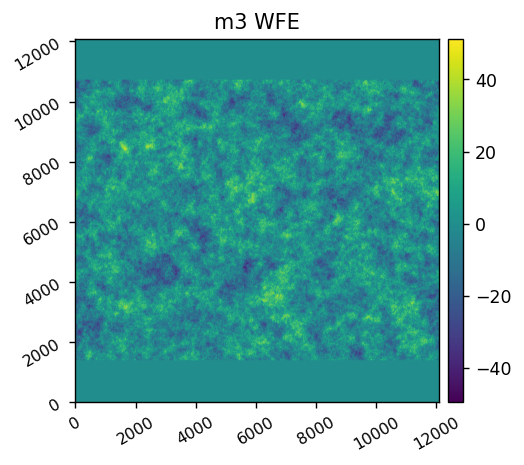

Saved data to:  ../stppsf/wfe-maps/m3_full.fits


In [14]:
reload(esc_optics)
optic = 'm3'
XD = esc_optics.diams[optic][0].to_value(u.m)
YD = esc_optics.diams[optic][1].to_value(u.m)

iwf = get_wf_index(optic)
pwf = wfs[iwf]
pxscl = pwf.pixelscale.to_value(u.m/u.pix)
N = int(np.ceil(XD/pxscl))
print(iwf, optic, wfs[iwf].location[5:])
print(f'\t Diam = {XD:.5f}, Pixelscale = {pxscl:.2e}, Dimensions = {N :d}\n')

# pupil_max_width = OD
a = 1  # Will be determined from wfe_rms
b = 10 # cycles/m
c = 2.65
wfe_rms = opd_rms_vals[optic].to_value(u.nm)

psd_tools = psd_utils.PSDUtils()
coords = psd_tools.coord_arrays((N,N), dx=pxscl)

pupil_mask = np.zeros((N,N))
pupil_mask[(np.abs(coords.x_grid) < (XD / 2)) & (np.abs(coords.y_grid) < (YD / 2))] = 1

psd = psd_tools.abc_psd(
    coords,
    a,
    b,
    c,
    rms=wfe_rms,
    k_min=None,
    k_max=None,
    rms_scaling=True,
    only_1d=False,
)

# create WFE map
seed = 123456
wfe = psd_tools.create_map(coords, psd, mask=pupil_mask, rms=wfe_rms, seed=seed)
imshow1(wfe.map, f'{optic} WFE', cmap='viridis')

hdr = {
    'PIXELSCL':pxscl,
    'RMS':wfe_rms, 
    'A':a,
    'B':b,
    'C':c,
}
utils.save_fits(f'../stppsf/wfe-maps/{optic}_full.fits', wfe.map, header=hdr)

# Now crop to only the regions of the optics that are significant in the Fresnel model.

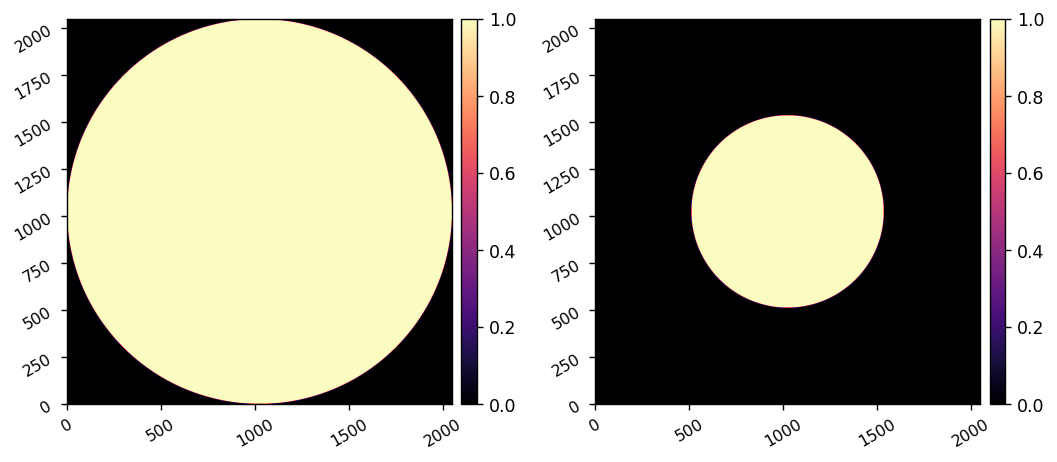

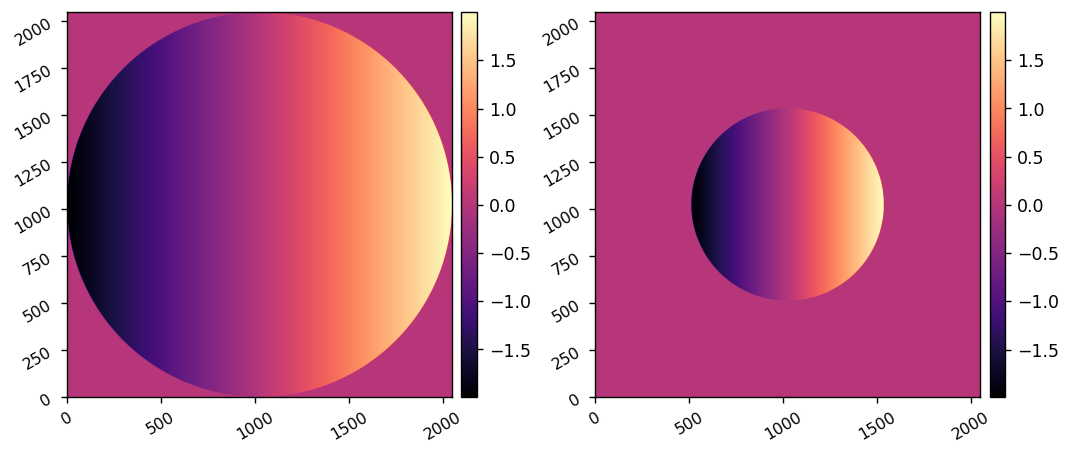

In [5]:
Nsub = 2048
y,x = np.indices((Nsub, Nsub)) - Nsub//2
r = np.sqrt(x**2 + y**2)
subap_mask = r<Nsub/2 
ptt_footprint_mask = r<Nsub/2/2 # define a smaller region from which we want to remove piston, tip, and tilt from

ptt_subap = utils.create_zernike_modes(xp.array(subap_mask), 3)
ptt_footprint = utils.create_zernike_modes(xp.array(ptt_footprint_mask), 3)
imshow2(subap_mask, ptt_footprint_mask)
imshow2(ptt_subap[1], ptt_footprint[1])

In [9]:
opd_keys = list(opd_rms_vals.keys())
for i in range(len(opd_keys)):
    optic = opd_keys[i]
    if optic=='m1': continue

    full_wfe = fits.getdata(f'../stppsf/wfe-maps/{optic}_full.fits')
    header = fits.getheader(f'../stppsf/wfe-maps/{optic}_full.fits')
    pxscl = header['PIXELSCL']
    wfe_rms = header['RMS']

    if optic=='m1':
        subap_shift = int(np.ceil((6.5/2-2.43/2) / pxscl))
        full_wfe = ensure_np_array(_scipy.ndimage.shift(xp.array(full_wfe), (0, subap_shift)))
    subap_wfe = utils.pad_or_crop(xp.array(full_wfe), Nsub) * xp.array(subap_mask)

    # Measure the PTT over just the footprint of the optic
    ptt_coeff = ensure_np_array(utils.lstsq(xp.array(ptt_footprint), xp.array(subap_wfe))) 
    # Subtract that PTT from the entire subaperture region we are using for WFE
    for i in range(3):
        subap_wfe -= ptt_coeff[i] * ptt_subap[i]

    subap_rms = xp.sqrt(xp.mean(xp.square(subap_wfe[subap_mask])))
    print(wfe_rms, subap_rms)

    hdr = {
        'PIXELSCL':pxscl,
        'RMS':wfe_rms, 
        'SUBAPRMS':float(subap_rms), 
        'A':header['A'],
        'B':header['B'],
        'C':header['C'],
    }
    utils.save_fits(f'../stppsf/wfe-maps/{optic}_subap.fits', subap_wfe, header=hdr)


16.0 16.875476166427028
Saved data to:  ../stppsf/wfe-maps/m2_subap.fits
10.0 10.706702683448876
Saved data to:  ../stppsf/wfe-maps/m3_subap.fits
10.0 10.0572575350517
Saved data to:  ../stppsf/wfe-maps/m4_subap.fits
6.0 5.341777983495523
Saved data to:  ../stppsf/wfe-maps/oap1_subap.fits
6.0 3.8311263402278306
Saved data to:  ../stppsf/wfe-maps/fm1_subap.fits
6.0 5.822204559959297
Saved data to:  ../stppsf/wfe-maps/oap2_subap.fits
6.0 6.347417456855132
Saved data to:  ../stppsf/wfe-maps/oap3_subap.fits
6.0 4.493526162246034
Saved data to:  ../stppsf/wfe-maps/fsm_subap.fits
6.0 5.967379662310111
Saved data to:  ../stppsf/wfe-maps/fm2_subap.fits
6.0 5.688332270305061
Saved data to:  ../stppsf/wfe-maps/oap4_subap.fits
6.0 5.0827545515191925
Saved data to:  ../stppsf/wfe-maps/oap5_subap.fits
6.0 6.070141261061736
Saved data to:  ../stppsf/wfe-maps/input_lp_subap.fits
6.0 5.916928998705315
Saved data to:  ../stppsf/wfe-maps/input_qwp_subap.fits
6.0 5.140004187780569
Saved data to:  ../stpp

# Now do the masking for the subaperture on M1

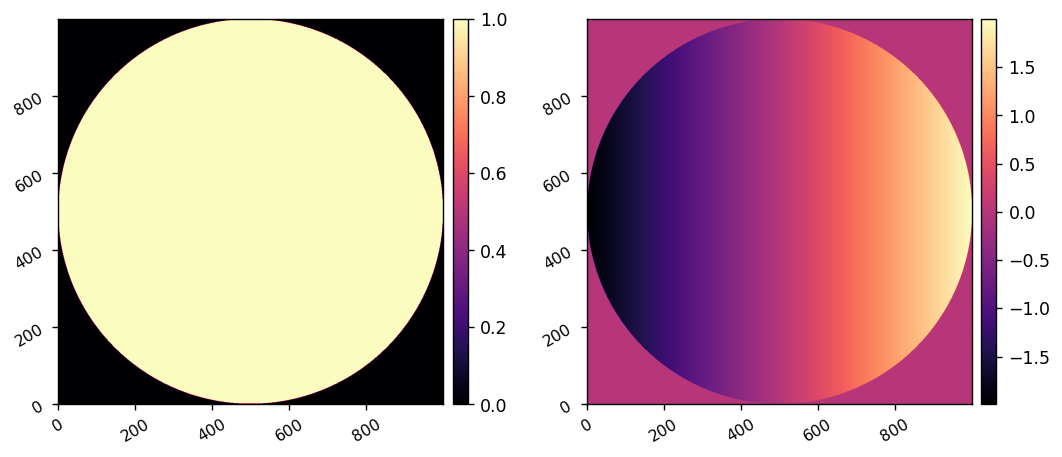

20.0 20.03782779318173
Saved data to:  ../stppsf/wfe-maps/m1_subap.fits


In [13]:
optic = 'm1'

Nsub = 1000
y,x = np.indices((Nsub, Nsub)) - Nsub//2
r = np.sqrt(x**2 + y**2)
subap_mask = r<Nsub/2 
ptt_subap = utils.create_zernike_modes(xp.array(subap_mask), 3)
imshow2(subap_mask, ptt_subap[1])

full_wfe = fits.getdata(f'../stppsf/wfe-maps/{optic}_full.fits')
header = fits.getheader(f'../stppsf/wfe-maps/{optic}_full.fits')
pxscl = header['PIXELSCL']
wfe_rms = header['RMS']

subap_shift = int(np.ceil((6.5/2-2.43/2) / pxscl))
full_wfe = ensure_np_array(_scipy.ndimage.shift(xp.array(full_wfe), (0, subap_shift)))
subap_wfe = utils.pad_or_crop(xp.array(full_wfe), Nsub) * xp.array(subap_mask)

# Measure the PTT over just the footprint of the optic
ptt_coeff = ensure_np_array(utils.lstsq(xp.array(ptt_subap), xp.array(subap_wfe))) 
for i in range(3):
    subap_wfe -= ptt_coeff[i] * ptt_subap[i]

subap_rms = xp.sqrt(xp.mean(xp.square(subap_wfe[subap_mask])))
print(wfe_rms, subap_rms)

hdr = {
    'PIXELSCL':pxscl,
    'RMS':wfe_rms, 
    'SUBAPRMS':float(subap_rms), 
    'A':header['A'],
    'B':header['B'],
    'C':header['C'],
}
utils.save_fits(f'../stppsf/wfe-maps/{optic}_subap.fits', subap_wfe, header=hdr)

# Test making a FITSOpticalElement to confirm it is valid. 

(2675, 2675) (1000, 1000)


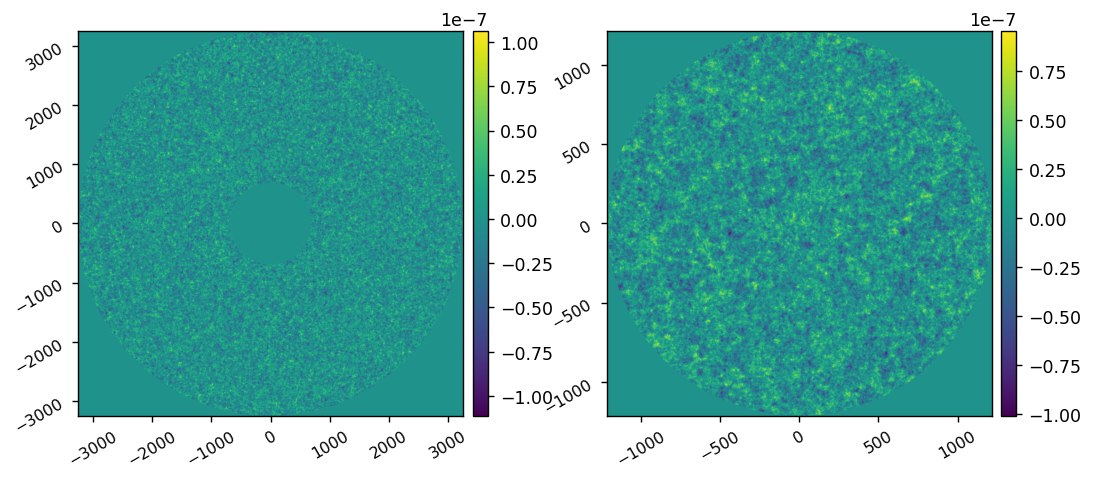

In [22]:
wfe_full = poppy.FITSOpticalElement(opd='../stppsf/wfe-maps/m1_full.fits', opdunits='nanometers', 
                               planetype=poppy.poppy_core.PlaneType.intermediate)
wfe_subap = poppy.FITSOpticalElement(opd='../stppsf/wfe-maps/m1_subap.fits', opdunits='nanometers', 
                               planetype=poppy.poppy_core.PlaneType.intermediate)
print(wfe_full.shape, wfe_subap.shape)                               
imshow2(wfe_full.opd, wfe_subap.opd, pxscl=wfe_full.pixelscale.to(u.mm/u.pix), cmap1='viridis', cmap2='viridis')

(6361, 6361) (2048, 2048)


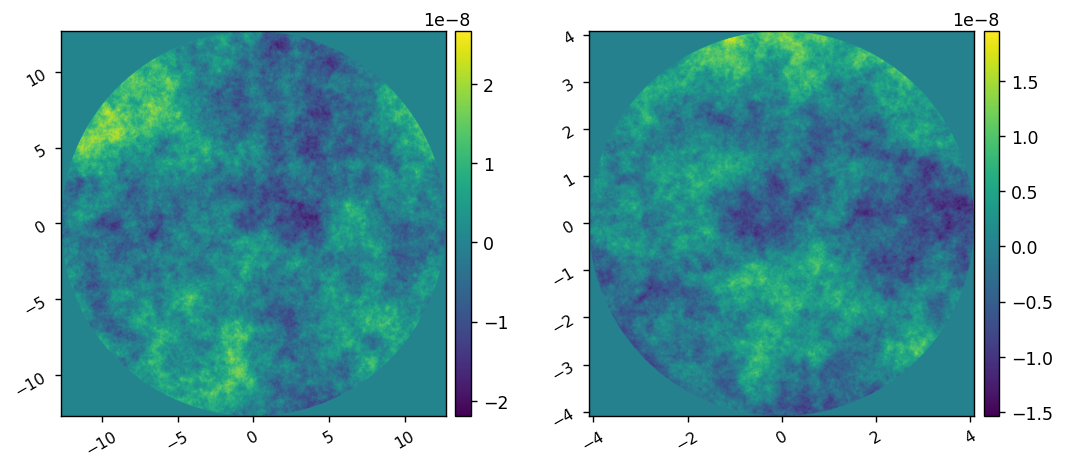

In [21]:
optic = 'oap10'
wfe_full = poppy.FITSOpticalElement(opd=f'../stppsf/wfe-maps/{optic}_full.fits', opdunits='nanometers', 
                               planetype=poppy.poppy_core.PlaneType.intermediate)
wfe_subap = poppy.FITSOpticalElement(opd=f'../stppsf/wfe-maps/{optic}_subap.fits', opdunits='nanometers', 
                               planetype=poppy.poppy_core.PlaneType.intermediate)
print(wfe_full.shape, wfe_subap.shape)
imshow2(wfe_full.opd, wfe_subap.opd, pxscl=wfe_full.pixelscale.to(u.mm/u.pix), cmap1='viridis', cmap2='viridis')